# 08. Causal ML Model Validation

Causal machine learning is hard to validate because the object we most want to predict is usually unobserved.

For an outcome model, validation is familiar because we compare predicted outcomes to observed outcomes. For a CATE model, the target is:

$$
\tau(x) = E[Y(1)-Y(0)\mid X=x]
$$

But for each individual we only observe one potential outcome. We do not observe both $Y(1)$ and $Y(0)$ for the same unit. That means ordinary prediction validation is not enough.

This notebook is a practical validation playbook for causal ML in industry. We will use simulation truth to learn what good validation looks like, then emphasize the diagnostics that remain available in real projects.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain why outcome-prediction accuracy is not the same as treatment-effect accuracy.
- Use simulation-only metrics such as PEHE to understand estimator behavior.
- Use held-out R-loss as a practical model-selection criterion.
- Validate CATE ranking with uplift and targeting curves.
- Estimate calibration of treatment-effect scores with doubly robust pseudo-outcomes.
- Evaluate top-k policy value under capacity constraints.
- Run placebo, stability, overlap, and drift checks before deployment.
- Translate causal ML validation into a professional model-risk readout.

### Dataset and Experiment Setup

The notebook uses simulated campaign or intervention data with heterogeneous treatment effects. The unit is a customer or account. Features capture pre-treatment risk, value, engagement, and operational context. The treatment is a campaign, offer, or intervention, and the outcome is a post-treatment response. The dataset also includes validation conditions such as overlap problems and distribution shift between development and evaluation samples.

This is synthetic data because validation of causal ML needs a known CATE for at least some diagnostics. In real data, PEHE and true individual effects are unavailable, so teams must rely on doubly robust scores, uplift curves, policy value, placebo checks, stability checks, and prospective experiments. The notebook uses known truth to explain what those diagnostics are trying to approximate. The realism comes from model drift, treatment imbalance, heterogeneous effects, and the possibility that a model that looks good in one sample performs poorly for the actual decision population.


In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def sigmoid(x):
    """Compute sigmoid for the causal ml model validation example.
    
    Inputs:
    - `x`: logit-scale numeric input converted into a probability.
    Returns: a NumPy array or scalar of logistic probabilities."""
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    """Construct the dag object.
    
    Inputs:
    - `edges`: directed or undirected graph edges represented as node pairs.
    - `title`: plot or graph title displayed above the figure.
    - `node_colors`: optional mapping from graph nodes to fill colors.
    - `rankdir`: Graphviz layout direction, such as left-to-right or top-to-bottom.
    Returns: a Graphviz diagram for the causal structure in the section."""
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def top_fraction_mask(scores, fraction, require_positive=False):
    """Compute top fraction mask for the causal ml model validation example.
    
    Inputs:
    - `scores`: array or Series of scores used to rank units before choosing who to treat.
    - `fraction`: fraction of units selected by a top-ranked targeting rule.
    - `require_positive`: whether to restrict treatment to units with positive predicted incremental value.
    Returns: a Boolean mask or treatment rule selecting the highest-scoring share of units."""
    scores = np.asarray(scores)
    if fraction <= 0:
        return np.zeros(len(scores), dtype=int)
    if fraction >= 1:
        mask = np.ones(len(scores), dtype=int)
    else:
        threshold = np.quantile(scores, 1 - fraction)
        mask = (scores >= threshold).astype(int)
    if require_positive:
        mask = mask * (scores > 0).astype(int)
    return mask


def bootstrap_ci(values, seed=1, n_boot=500, alpha=0.05):
    """Bootstrap an uncertainty interval for a one-dimensional diagnostic.
    
    Inputs:
    - `values`: numeric values being averaged, resampled, demeaned, or summarized.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `n_boot`: number of bootstrap resamples used to form the uncertainty interval.
    - `alpha`: significance level or exposure saturation parameter, depending on the function.
    Returns: a tuple with lower, median, and upper bootstrap quantiles."""
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    boot = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(values), len(values))
        boot.append(values[idx].mean())
    return np.quantile(boot, [alpha / 2, 1 - alpha / 2])

## 1. Why Causal ML Validation Is Different

The fundamental problem is that treatment effects are not directly observed. We observe:

$$
Y = WY(1) + (1-W)Y(0)
$$

but the individual effect:

$$
Y(1)-Y(0)
$$

is never observed for the same unit.

This creates a validation trap. A model can predict outcomes well while being bad at treatment effects. Outcome prediction mainly rewards learning the baseline outcome function:

$$
m(x)=E[Y\mid X=x]
$$

Causal personalization needs the difference between potential outcomes:

$$
\tau(x)=E[Y(1)-Y(0)\mid X=x]
$$

These are related but not the same target. Rothenhausler (2020) emphasizes that ordinary predictive cross-validation can select models that are not optimal for causal parameters. Gao et al. (2020) also describe the central difficulty: HTE accuracy is hard to assess because HTE itself is invisible in ordinary validation data.

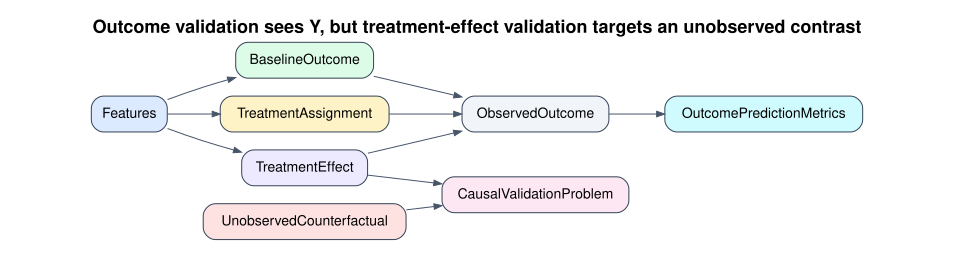

In [3]:
make_dag(
    edges=[
        ("Features", "TreatmentAssignment"),
        ("Features", "BaselineOutcome"),
        ("Features", "TreatmentEffect"),
        ("TreatmentAssignment", "ObservedOutcome"),
        ("BaselineOutcome", "ObservedOutcome"),
        ("TreatmentEffect", "ObservedOutcome"),
        ("ObservedOutcome", "OutcomePredictionMetrics"),
        ("UnobservedCounterfactual", "CausalValidationProblem"),
        ("TreatmentEffect", "CausalValidationProblem"),
    ],
    title="Outcome validation sees Y, but treatment-effect validation targets an unobserved contrast",
    node_colors={
        "Features": "#dbeafe",
        "TreatmentAssignment": "#fef3c7",
        "BaselineOutcome": "#dcfce7",
        "TreatmentEffect": "#ede9fe",
        "ObservedOutcome": "#f1f5f9",
        "OutcomePredictionMetrics": "#cffafe",
        "UnobservedCounterfactual": "#fee2e2",
        "CausalValidationProblem": "#fce7f3",
    },
)

## 2. Validation Targets

A causal ML validation plan usually separates five questions:

1. Identification: are the causal assumptions plausible?
2. Nuisance quality: are propensity and outcome models usable?
3. Effect estimation: do CATE scores estimate effect magnitudes?
4. Ranking quality: do high-scored units really have larger effects?
5. Decision value: does the treatment policy improve outcomes after costs and constraints?

In simulation, we can directly check CATE error:

$$
PEHE = \sqrt{\frac{1}{n}\sum_{i}(\hat{\tau}(X_i)-\tau(X_i))^2}
$$

In real data, PEHE is unavailable. We use proxies: R-loss, doubly robust calibration, uplift curves, policy value, placebo checks, stability checks, and prospective experiments.

## 3. Running Example: Promotional Retention Campaign

Imagine a subscription company deciding who should receive a retention promotion. The outcome is next-period account value. The treatment is a promotion plus outreach workflow.

The true effect is heterogeneous:

- Some high-risk, high-value accounts are persuadable.
- Some very unhealthy accounts are hard to save.
- Some low-risk accounts would renew anyway.
- Some discount-sensitive customers respond to incentives.

We will simulate observational data with confounding, then fit several causal ML scores and validate them on held-out data.

In [4]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
def simulate_campaign_data(n=11000, seed=5808, shifted=False):
    """Simulate the campaign data data-generating process.
    
    Inputs:
    - `n`: number of simulated units or records to generate for the teaching example.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    - `shifted`: shifted value used by `simulate_campaign_data`.
    Returns: a pandas DataFrame with generated covariates, treatment or policy variables, outcomes, and teaching diagnostics for this scenario."""
    rng = np.random.default_rng(seed)

    churn_risk = rng.beta(2.2, 2.5, n)
    product_health = rng.beta(2.6, 2.1, n)
    discount_sensitivity = rng.beta(2.1, 2.7, n)
    usage_depth = rng.normal(0, 1, n)
    log_mrr = rng.normal(4.4, 0.62, n)
    mrr_z = (log_mrr - log_mrr.mean()) / log_mrr.std()
    enterprise = rng.binomial(1, sigmoid(-0.35 + 0.9 * mrr_z + 0.35 * churn_risk), n)
    onboarding_gap = rng.beta(1.8, 3.1, n)
    support_load = rng.poisson(np.clip(0.3 + 3.1 * churn_risk - 0.8 * product_health + 0.7 * enterprise, 0.05, None))
    region_west = rng.binomial(1, 0.33, n)
    region_emea = rng.binomial(1, 0.27, n) * (1 - region_west)

    if shifted:
        churn_risk = np.clip(0.08 + 0.92 * churn_risk, 0, 1)
        product_health = np.clip(product_health - 0.08 + rng.normal(0, 0.03, n), 0, 1)
        discount_sensitivity = np.clip(discount_sensitivity + 0.07, 0, 1)
        support_load = support_load + rng.poisson(0.35, n)

    severe_risk = ((churn_risk > 0.78) & (product_health < 0.25)).astype(float)
    reachable_risk = churn_risk * (1 - product_health)
    high_value_need = enterprise * (churn_risk > 0.45).astype(float)

    propensity = sigmoid(
        -0.95
        + 1.85 * churn_risk
        - 1.15 * product_health
        + 0.65 * enterprise
        + 0.55 * discount_sensitivity
        + 0.42 * onboarding_gap
        + 0.20 * support_load
        + 0.22 * mrr_z
    )
    propensity = np.clip(propensity, 0.06, 0.94)
    treatment = rng.binomial(1, propensity, n)

    baseline = (
        62
        + 12.0 * mrr_z
        + 19.0 * product_health
        - 27.0 * churn_risk
        + 6.0 * enterprise
        + 3.0 * usage_depth
        - 1.7 * support_load
        - 7.0 * onboarding_gap
        + 2.3 * region_west
        - 1.2 * region_emea
        + 3.5 * np.sin(usage_depth)
    )

    tau = (
        2.5
        + 40.0 * reachable_risk
        + 8.0 * high_value_need
        + 11.0 * discount_sensitivity * churn_risk
        + 6.0 * onboarding_gap
        - 16.0 * severe_risk
        - 2.2 * np.maximum(support_load - 4, 0)
        + 2.0 * region_emea
    )
    tau = np.clip(tau, -12, 48)
    outcome = baseline + treatment * tau + rng.normal(0, 8.0, n)

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "churn_risk": churn_risk,
            "product_health": product_health,
            "discount_sensitivity": discount_sensitivity,
            "usage_depth": usage_depth,
            "log_mrr": log_mrr,
            "mrr_z": mrr_z,
            "enterprise": enterprise,
            "onboarding_gap": onboarding_gap,
            "support_load": support_load,
            "region_west": region_west,
            "region_emea": region_emea,
            "propensity": propensity,
            "treatment": treatment,
            "baseline": baseline,
            "true_tau": tau,
            "outcome": outcome,
        }
    )


df = simulate_campaign_data()
feature_cols = [
    "churn_risk",
    "product_health",
    "discount_sensitivity",
    "usage_depth",
    "mrr_z",
    "enterprise",
    "onboarding_gap",
    "support_load",
    "region_west",
    "region_emea",
]

df.head()

,account_id,churn_risk,product_health,discount_sensitivity,usage_depth,log_mrr,mrr_z,enterprise,onboarding_gap,support_load,region_west,region_emea,propensity,treatment,baseline,true_tau,outcome
0,1,0.627,0.814,0.620,0.665,4.654,0.406,1,0.729,3,1,0,0.779,1,67.679,23.810,93.935
1,2,0.474,0.843,0.694,-0.982,4.528,0.203,1,0.673,2,0,1,0.672,1,58.488,23.139,75.721
2,3,0.661,0.162,0.223,1.651,4.724,0.519,0,0.364,3,0,0,0.746,1,54.240,28.474,97.196
3,4,0.158,0.431,0.792,0.955,4.986,0.940,1,0.388,0,0,0,0.575,1,86.212,9.795,100.562
4,5,0.710,0.652,0.352,1.187,4.755,0.568,1,0.689,2,0,0,0.781,1,66.608,27.269,104.903


This is where the calculation starts to matter for the decision. A useful CATE score has to survive calibration, overlap, stability, robustness, and policy-value checks.

In [5]:
summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Treatment rate",
            "Average observed outcome",
            "Average true CATE",
            "Share with positive true effect",
            "Propensity min",
            "Propensity max",
        ],
        "value": [
            len(df),
            df["treatment"].mean(),
            df["outcome"].mean(),
            df["true_tau"].mean(),
            (df["true_tau"] > 0).mean(),
            df["propensity"].min(),
            df["propensity"].max(),
        ],
    }
)
display(summary)

,quantity,value
0,Accounts,11000.000
1,Treatment rate,0.557
2,Average observed outcome,68.545
3,Average true CATE,17.288
4,Share with positive true effect,1.000
5,Propensity min,0.121
6,Propensity max,0.940


The result matters when it changes the next decision. Validation asks whether the score would make better treatment decisions, including cases where a predictive-looking pattern has little policy value.

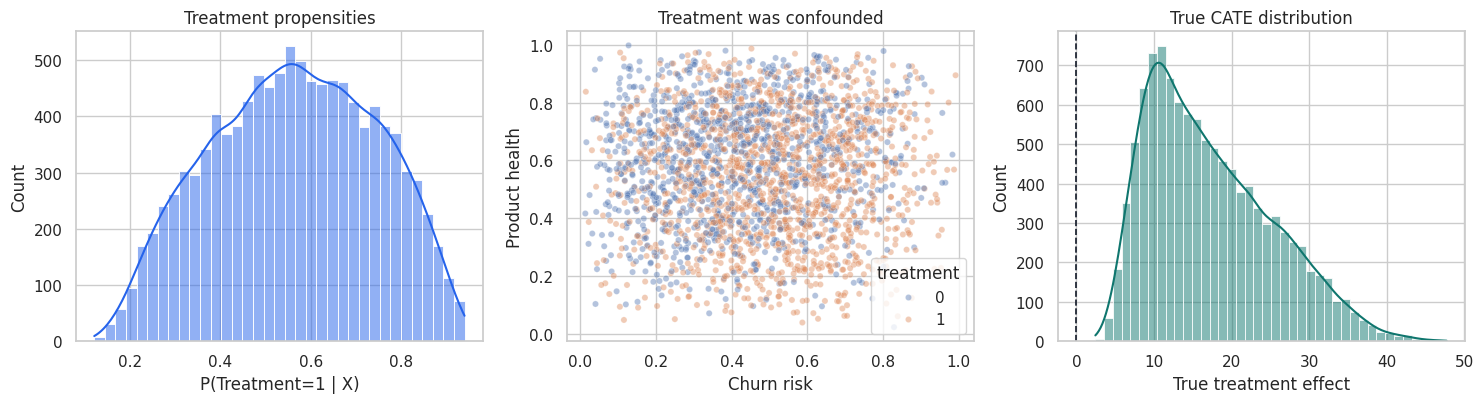

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

sns.histplot(df["propensity"], bins=35, kde=True, color="#2563eb", ax=axes[0])
axes[0].set_title("Treatment propensities")
axes[0].set_xlabel("P(Treatment=1 | X)")

sns.scatterplot(
    data=df.sample(2500, random_state=3),
    x="churn_risk",
    y="product_health",
    hue="treatment",
    alpha=0.42,
    s=20,
    ax=axes[1],
)
axes[1].set_title("Treatment was confounded")
axes[1].set_xlabel("Churn risk")
axes[1].set_ylabel("Product health")

sns.histplot(df["true_tau"], bins=40, kde=True, color="#0f766e", ax=axes[2])
axes[2].axvline(0, color="#111827", linestyle="--", linewidth=1.2)
axes[2].set_title("True CATE distribution")
axes[2].set_xlabel("True treatment effect")

plt.tight_layout()
plt.show()

The simulation gives us a teaching luxury, the true treatment effect for every account. We will use it carefully and clearly mark which diagnostics are simulation-only and which are usable in real projects.

## 4. Train, Validation, and Honest Scoring

Validation must be honest. We will:

1. Split the data into model-training and validation samples.
2. Fit CATE candidate models only on the training sample.
3. Fit nuisance models on the training sample and score the validation sample.
4. Compare candidate CATE scores on the held-out validation sample.

This avoids judging a causal score on the same observations used to fit it.

In [7]:
train_idx, val_idx = train_test_split(
    df.index,
    test_size=0.40,
    random_state=5810,
    stratify=df["treatment"],
)
train = df.loc[train_idx].copy()
valid = df.loc[val_idx].copy()

len(train), len(valid), train["treatment"].mean(), valid["treatment"].mean()

(6600, 4400, np.float64(0.556969696969697), np.float64(0.5568181818181818))

## 5. Candidate CATE Models

We will compare several scores:

- ATE baseline: predicts the same effect for everyone.
- Risk-only score: ranks by churn risk, a common but noncausal business shortcut.
- S-learner: one outcome model with treatment and treatment interactions.
- T-learner: separate outcome models for treated and untreated observations.
- R-learner style score: residualizes outcome and treatment, then learns treatment-effect heterogeneity.
- Placebo shuffled-treatment score: a negative-control model trained after shuffling treatment labels.

The placebo score should not validate well. It is a useful reminder that a flexible model can create impressive-looking heterogeneity out of noise.

In [8]:
# Define reusable helpers so the later analytical cells stay focused on the causal argument.
def add_treatment_features(frame, treatment_values):
    """Create S-learner feature rows under specified treatment values.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `treatment_values`: set of treatment values used to create counterfactual prediction rows.
    Returns: a DataFrame that repeats covariates with treatment columns set to the requested values."""
    base = frame[feature_cols].reset_index(drop=True).copy()
    treatment_values = np.asarray(treatment_values)
    base["treatment"] = treatment_values
    for col in feature_cols:
        base[f"treatment_x_{col}"] = treatment_values * base[col].to_numpy()
    return base


def fit_s_learner(train_frame):
    """Fit the s learner model or estimator.
    
    Inputs:
    - `train_frame`: training DataFrame used to fit the learner before predicting treatment effects elsewhere.
    Returns: fitted model objects or a structured result used by the estimator in this notebook."""
    model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=5811,
    )
    X = add_treatment_features(train_frame, train_frame["treatment"].to_numpy())
    model.fit(X, train_frame["outcome"])
    return model


def predict_s_learner(model, frame):
    """Generate s learner predictions.
    
    Inputs:
    - `model`: fitted statistical or machine-learning model whose coefficients or predictions are being used.
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: predicted effects, rewards, or outcomes for the rows passed into the function."""
    x1 = add_treatment_features(frame, np.ones(len(frame)))
    x0 = add_treatment_features(frame, np.zeros(len(frame)))
    return model.predict(x1) - model.predict(x0)


def fit_t_learner(train_frame, seed=5812):
    """Fit the t learner model or estimator.
    
    Inputs:
    - `train_frame`: training DataFrame used to fit the learner before predicting treatment effects elsewhere.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: fitted model objects or a structured result used by the estimator in this notebook."""
    base_model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=40,
        l2_regularization=0.025,
        random_state=seed,
    )
    m1 = clone(base_model)
    m0 = clone(base_model)
    m1.fit(train_frame.loc[train_frame["treatment"] == 1, feature_cols], train_frame.loc[train_frame["treatment"] == 1, "outcome"])
    m0.fit(train_frame.loc[train_frame["treatment"] == 0, feature_cols], train_frame.loc[train_frame["treatment"] == 0, "outcome"])
    return m1, m0


def predict_t_learner(models, frame):
    """Generate t learner predictions.
    
    Inputs:
    - `models`: collection of fitted action-specific or treatment-specific models.
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: predicted effects, rewards, or outcomes for the rows passed into the function."""
    m1, m0 = models
    return m1.predict(frame[feature_cols]) - m0.predict(frame[feature_cols])


def crossfit_nuisance_for_r_learner(train_frame, n_splits=5, seed=5813):
    """Build cross-fitted nuisance for r learner quantities.
    
    Inputs:
    - `train_frame`: training DataFrame used to fit the learner before predicting treatment effects elsewhere.
    - `n_splits`: number of folds used for cross-fitting so rows are predicted out of sample.
    - `seed`: integer random seed that makes the simulation or model split reproducible.
    Returns: out-of-fold predictions or scores built without using each row to predict itself."""
    n = len(train_frame)
    m_hat = np.zeros(n)
    e_hat = np.zeros(n)
    fold_id = np.zeros(n, dtype=int)

    outcome_model = HistGradientBoostingRegressor(
        max_iter=160,
        learning_rate=0.05,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=seed,
    )
    propensity_model = HistGradientBoostingClassifier(
        max_iter=160,
        learning_rate=0.05,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=seed + 1,
    )
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    for fold, (fit_idx, pred_idx) in enumerate(kfold.split(train_frame), start=1):
        fit = train_frame.iloc[fit_idx]
        pred = train_frame.iloc[pred_idx]
        om = clone(outcome_model)
        pm = clone(propensity_model)
        om.fit(fit[feature_cols], fit["outcome"])
        pm.fit(fit[feature_cols], fit["treatment"])
        m_hat[pred_idx] = om.predict(pred[feature_cols])
        e_hat[pred_idx] = np.clip(pm.predict_proba(pred[feature_cols])[:, 1], 0.04, 0.96)
        fold_id[pred_idx] = fold
    return m_hat, e_hat, fold_id


def fit_r_learner(train_frame):
    """Fit the r learner model or estimator.
    
    Inputs:
    - `train_frame`: training DataFrame used to fit the learner before predicting treatment effects elsewhere.
    Returns: fitted model objects or a structured result used by the estimator in this notebook."""
    m_hat, e_hat, _ = crossfit_nuisance_for_r_learner(train_frame)
    y_res = train_frame["outcome"].to_numpy() - m_hat
    w_res = train_frame["treatment"].to_numpy() - e_hat
    pseudo_target = y_res / np.where(np.abs(w_res) < 0.05, np.sign(w_res) * 0.05 + (w_res == 0) * 0.05, w_res)
    weights = np.clip(w_res**2, 0.0025, None)
    tau_model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=5814,
    )
    tau_model.fit(train_frame[feature_cols], pseudo_target, sample_weight=weights)
    return tau_model


def fit_nuisance_for_validation(train_frame):
    """Fit the nuisance for validation model or estimator.
    
    Inputs:
    - `train_frame`: training DataFrame used to fit the learner before predicting treatment effects elsewhere.
    Returns: fitted model objects or a structured result used by the estimator in this notebook."""
    outcome_model = HistGradientBoostingRegressor(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=5815,
    )
    propensity_model = HistGradientBoostingClassifier(
        max_iter=180,
        learning_rate=0.045,
        min_samples_leaf=45,
        l2_regularization=0.03,
        random_state=5816,
    )
    m1, m0 = fit_t_learner(train_frame, seed=5817)
    m = clone(outcome_model)
    e = clone(propensity_model)
    m.fit(train_frame[feature_cols], train_frame["outcome"])
    e.fit(train_frame[feature_cols], train_frame["treatment"])
    return m, e, m1, m0

In [9]:
s_model = fit_s_learner(train)
t_models = fit_t_learner(train)
r_model = fit_r_learner(train)
nuisance_m, nuisance_e, nuisance_m1, nuisance_m0 = fit_nuisance_for_validation(train)

rng = np.random.default_rng(5818)
placebo_train = train.copy()
placebo_train["treatment"] = rng.permutation(placebo_train["treatment"].to_numpy())
placebo_t_models = fit_t_learner(placebo_train, seed=5819)

ate_hat = (
    train.loc[train["treatment"] == 1, "outcome"].mean()
    - train.loc[train["treatment"] == 0, "outcome"].mean()
)

valid_scores = pd.DataFrame(index=valid.index)
valid_scores["ATE baseline"] = ate_hat
valid_scores["Risk-only score"] = 35 * (valid["churn_risk"] - valid["churn_risk"].mean())
valid_scores["S-learner"] = predict_s_learner(s_model, valid)
valid_scores["T-learner"] = predict_t_learner(t_models, valid)
valid_scores["R-learner style"] = r_model.predict(valid[feature_cols])
valid_scores["Placebo shuffled treatment"] = predict_t_learner(placebo_t_models, valid)

valid_eval = valid.join(valid_scores)
valid_eval.head()

,account_id,churn_risk,product_health,discount_sensitivity,usage_depth,log_mrr,mrr_z,enterprise,onboarding_gap,support_load,...,treatment,baseline,true_tau,outcome,ATE baseline,Risk-only score,S-learner,T-learner,R-learner style,Placebo shuffled treatment
3591,3592,0.284,0.797,0.133,1.174,4.073,-0.530,0,0.183,0,...,0,68.566,6.326,71.706,19.805,-6.253,4.419,4.857,5.161,3.495
7686,7687,0.089,0.648,0.701,-1.059,4.317,-0.137,1,0.224,1,...,0,66.772,5.779,57.065,19.805,-13.097,3.226,6.323,9.117,-3.517
8745,8746,0.730,0.537,0.079,0.243,3.088,-2.115,0,0.490,3,...,1,22.436,19.606,41.287,19.805,9.361,17.396,13.429,11.406,-0.196
7984,7985,0.547,0.265,0.325,-0.541,4.924,0.841,0,0.603,0,...,1,53.500,26.164,90.063,19.805,2.954,19.980,26.434,31.962,-0.632
9957,9958,0.308,0.825,0.584,0.289,4.695,0.471,1,0.311,0,...,0,80.704,8.501,85.448,19.805,-5.418,12.174,8.776,10.608,5.446


A result like this should lead to a concrete follow-up. The model earns trust by ranking effects well and by staying stable where the data have support.

## 6. Simulation-Only Metric: PEHE

The precision in estimating heterogeneous effects is:

$$
PEHE(\hat{\tau}) =
\sqrt{\frac{1}{n}\sum_{i}(\hat{\tau}(X_i)-\tau(X_i))^2}
$$

PEHE is excellent for simulation studies and benchmark datasets where potential outcomes are known by construction. It is not available in ordinary business data.

In [10]:
candidate_cols = list(valid_scores.columns)

pehe_rows = []
for col in candidate_cols:
    error = valid_eval[col] - valid_eval["true_tau"]
    pehe_rows.append(
        {
            "model": col,
            "PEHE_simulation_only": np.sqrt(np.mean(error**2)),
            "bias": np.mean(error),
            "corr_with_true_tau": pd.Series(valid_eval[col]).corr(valid_eval["true_tau"], method="spearman"),
        }
    )

pehe_table = pd.DataFrame(pehe_rows).sort_values("PEHE_simulation_only")
display(pehe_table)

,model,PEHE_simulation_only,bias,corr_with_true_tau
2,S-learner,3.524,-0.644,0.913
4,R-learner style,3.586,-0.488,0.912
3,T-learner,4.060,-0.468,0.885
0,ATE baseline,8.438,2.593,NaN
1,Risk-only score,18.089,-17.212,0.780
5,Placebo shuffled treatment,19.773,-17.409,-0.035


This checkpoint is about credibility and estimation together. A useful CATE score has to survive calibration, overlap, stability, robustness, and policy-value checks.

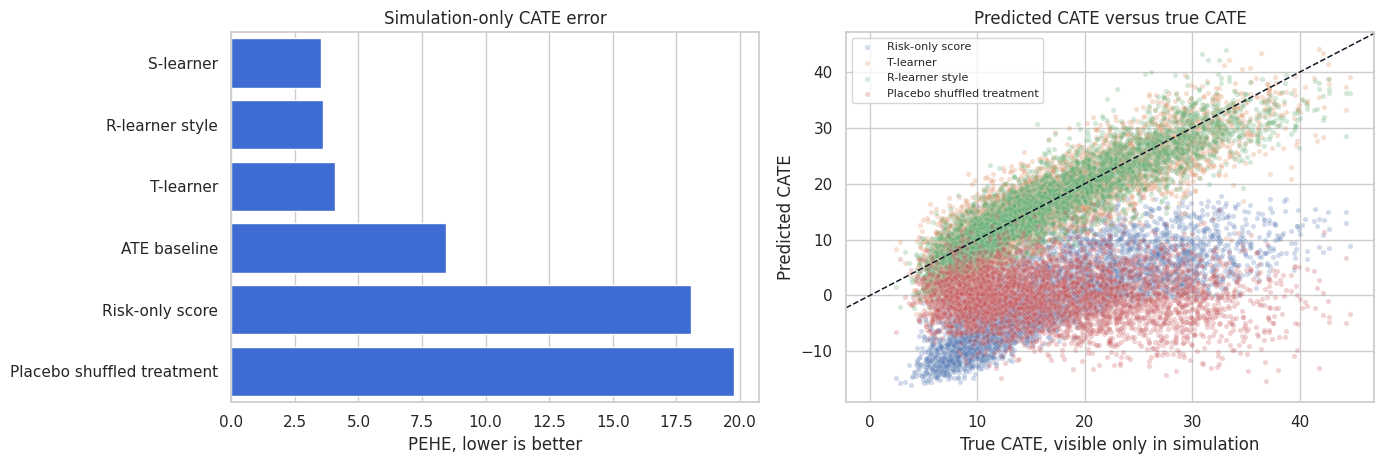

In [11]:
# Fit the models for this section and assemble the estimates used in the discussion.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

sns.barplot(
    data=pehe_table,
    y="model",
    x="PEHE_simulation_only",
    color="#2563eb",
    ax=axes[0],
)
axes[0].set_title("Simulation-only CATE error")
axes[0].set_xlabel("PEHE, lower is better")
axes[0].set_ylabel("")

for col in ["Risk-only score", "T-learner", "R-learner style", "Placebo shuffled treatment"]:
    sns.scatterplot(
        x=valid_eval["true_tau"],
        y=valid_eval[col],
        alpha=0.25,
        s=14,
        label=col,
        ax=axes[1],
    )
axes[1].axline((0, 0), slope=1, color="#111827", linestyle="--", linewidth=1.1)
axes[1].set_title("Predicted CATE versus true CATE")
axes[1].set_xlabel("True CATE, visible only in simulation")
axes[1].set_ylabel("Predicted CATE")
axes[1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()

PEHE teaches an important lesson: models that look plausible can still miss the treatment-effect function. The risk-only score may be useful for prioritizing churn prevention, but it is not necessarily a causal effect score. The placebo model should fail here; if it does not, the validation design is too weak.

## 7. Outcome Prediction Is Not Enough

Outcome prediction can be excellent even when CATE ranking is weak. A model can learn that high-value, healthy accounts have better outcomes while learning little about who is persuadable.

Here we compare:

- Outcome prediction quality.
- Treatment-effect ranking quality.

They are not the same metric.

In [12]:
# Fit the models for this section and assemble the estimates used in the discussion.
observed_features_train = train[feature_cols + ["treatment"]].copy()
observed_features_valid = valid[feature_cols + ["treatment"]].copy()

outcome_predictor = HistGradientBoostingRegressor(
    max_iter=180,
    learning_rate=0.045,
    min_samples_leaf=45,
    l2_regularization=0.03,
    random_state=5820,
)
outcome_predictor.fit(observed_features_train, train["outcome"])
outcome_pred = outcome_predictor.predict(observed_features_valid)

outcome_vs_causal = pd.DataFrame(
    {
        "metric": [
            "Outcome RMSE",
            "Outcome R2",
            "Spearman correlation: outcome prediction vs true CATE",
            "Spearman correlation: R-learner score vs true CATE",
        ],
        "value": [
            np.sqrt(mean_squared_error(valid["outcome"], outcome_pred)),
            r2_score(valid["outcome"], outcome_pred),
            pd.Series(outcome_pred).corr(valid["true_tau"], method="spearman"),
            valid_eval["R-learner style"].corr(valid_eval["true_tau"], method="spearman"),
        ],
    }
)
display(outcome_vs_causal)

,metric,value
0,Outcome RMSE,8.361
1,Outcome R2,0.834
2,Spearman correlation: outcome prediction vs tr...,0.027
3,Spearman correlation: R-learner score vs true ...,0.912


Good outcome prediction is useful for nuisance modeling, but it is not a sufficient validation of a treatment-effect model. A causal ML readout should not lead with ordinary RMSE or AUC unless the target is actually outcome prediction.

## 8. Held-Out R-Loss

The R-learner motivates a validation loss for treatment effects. Estimate nuisance functions:

$$
m(x) = E[Y\mid X=x]
$$

$$
e(x) = P(W=1\mid X=x)
$$

Then evaluate CATE scores with:

$$
L_R(\hat{\tau}) =
\frac{1}{n}\sum_{i}
\left[
\{Y_i-\hat{m}(X_i)\}
-
\hat{\tau}(X_i)\{W_i-\hat{e}(X_i)\}
\right]^2
$$

Nie and Wager (2020) show how residualized losses can be used for heterogeneous treatment-effect estimation. In validation, R-loss is attractive because it is computable without knowing the true CATE.

In [13]:
# Fit the models for this section and assemble the estimates used in the discussion.
valid_m_hat = nuisance_m.predict(valid[feature_cols])
valid_e_hat = np.clip(nuisance_e.predict_proba(valid[feature_cols])[:, 1], 0.04, 0.96)
valid_mu1_hat = nuisance_m1.predict(valid[feature_cols])
valid_mu0_hat = nuisance_m0.predict(valid[feature_cols])

valid_eval["m_hat"] = valid_m_hat
valid_eval["e_hat"] = valid_e_hat
valid_eval["mu1_hat"] = valid_mu1_hat
valid_eval["mu0_hat"] = valid_mu0_hat

def r_loss(frame, score_col):
    """Evaluate an R-learner score with residualized outcomes and treatments.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_col`: name of the model-score column used for ranking, targeting, or validation.
    Returns: a scalar R-loss value, where smaller values indicate better residual treatment-effect prediction."""
    y_res = frame["outcome"].to_numpy() - frame["m_hat"].to_numpy()
    w_res = frame["treatment"].to_numpy() - frame["e_hat"].to_numpy()
    tau_hat = frame[score_col].to_numpy()
    return np.mean((y_res - tau_hat * w_res) ** 2)


r_loss_table = pd.DataFrame(
    [
        {
            "model": col,
            "heldout_r_loss": r_loss(valid_eval, col),
            "PEHE_simulation_only": np.sqrt(np.mean((valid_eval[col] - valid_eval["true_tau"]) ** 2)),
        }
        for col in candidate_cols
    ]
).sort_values("heldout_r_loss")

display(r_loss_table)

,model,heldout_r_loss,PEHE_simulation_only
2,S-learner,72.845,3.524
4,R-learner style,73.101,3.586
3,T-learner,73.578,4.060
0,ATE baseline,84.690,8.438
1,Risk-only score,138.903,18.089
5,Placebo shuffled treatment,145.470,19.773


The point is to connect the number to the decision it supports. Validation asks whether the score would make better treatment decisions, including cases where a predictive-looking pattern has little policy value.

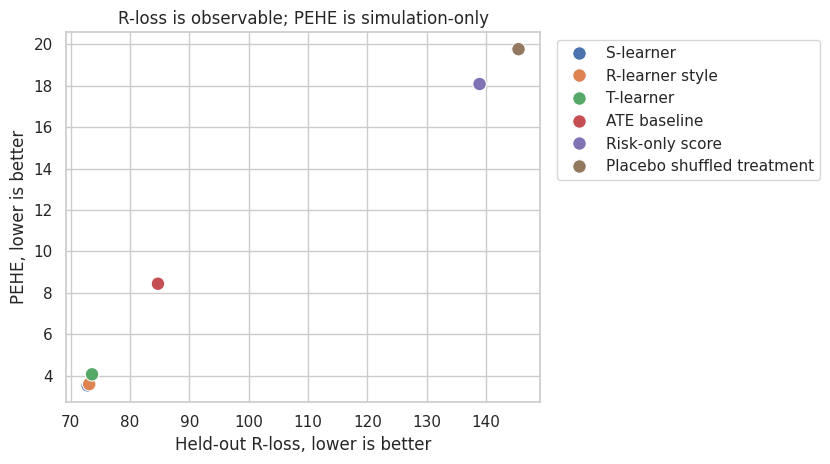

In [14]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.scatterplot(
    data=r_loss_table,
    x="heldout_r_loss",
    y="PEHE_simulation_only",
    hue="model",
    s=95,
    ax=ax,
)
ax.set_title("R-loss is observable; PEHE is simulation-only")
ax.set_xlabel("Held-out R-loss, lower is better")
ax.set_ylabel("PEHE, lower is better")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

R-loss is not perfect. It depends on nuisance quality, and it is not a business-value metric. But it is often a better model-selection signal than ordinary outcome prediction error because it directly evaluates the residualized treatment-effect moment.

## 9. Doubly Robust Pseudo-Outcomes for Calibration

A doubly robust pseudo-outcome for the CATE is:

$$
\Gamma_i =
\hat{\mu}_1(X_i)
+ \frac{W_i}{\hat{e}(X_i)}\{Y_i-\hat{\mu}_1(X_i)\}
-
\hat{\mu}_0(X_i)
- \frac{1-W_i}{1-\hat{e}(X_i)}\{Y_i-\hat{\mu}_0(X_i)\}
$$

This pseudo-outcome is noisy at the individual level, but it is useful after grouping. If a model says a decile has average treatment effect 20, the doubly robust estimate for that decile should be near 20.

Xu and Yadlowsky (2022) study calibration error for heterogeneous treatment effects and connect treatment-effect validation to calibration ideas from predictive modeling.

In [15]:
# Fit the models for this section and assemble the estimates used in the discussion.
def dr_cate_pseudo_outcome(frame):
    """Construct a doubly robust pseudo-outcome for CATE validation.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    Returns: a NumPy array of pseudo-outcomes that can be averaged by score bins."""
    w = frame["treatment"].to_numpy()
    y = frame["outcome"].to_numpy()
    e = frame["e_hat"].to_numpy()
    mu1 = frame["mu1_hat"].to_numpy()
    mu0 = frame["mu0_hat"].to_numpy()
    gamma1 = mu1 + (w / e) * (y - mu1)
    gamma0 = mu0 + ((1 - w) / (1 - e)) * (y - mu0)
    return gamma1 - gamma0


valid_eval["dr_pseudo_tau"] = dr_cate_pseudo_outcome(valid_eval)

calibration_rows = []
for col in candidate_cols:
    temp = valid_eval[[col, "dr_pseudo_tau", "true_tau"]].copy()
    temp["score_bin"] = pd.qcut(temp[col].rank(method="first"), 10, labels=False)
    grouped = (
        temp.groupby("score_bin", as_index=False)
        .agg(
            avg_pred=(col, "mean"),
            avg_dr=("dr_pseudo_tau", "mean"),
            avg_true=("true_tau", "mean"),
            n=(col, "size"),
        )
    )
    grouped["model"] = col
    calibration_rows.append(grouped)

calibration_df = pd.concat(calibration_rows, ignore_index=True)

calibration_summary = []
for col in candidate_cols:
    g = calibration_df[calibration_df["model"] == col]
    slope, intercept = np.polyfit(g["avg_pred"], g["avg_dr"], 1)
    calibration_summary.append(
        {
            "model": col,
            "dr_calibration_slope": slope,
            "dr_calibration_intercept": intercept,
            "decile_dr_true_corr": g["avg_dr"].corr(g["avg_true"]),
        }
    )

display(pd.DataFrame(calibration_summary).sort_values("decile_dr_true_corr", ascending=False))

,model,dr_calibration_slope,dr_calibration_intercept,decile_dr_true_corr
4,R-learner style,0.858,2.614,0.993
2,S-learner,0.939,1.403,0.989
1,Risk-only score,0.803,16.968,0.980
3,T-learner,0.819,3.251,0.980
5,Placebo shuffled treatment,-0.067,16.955,0.689
0,ATE baseline,0.428,8.484,-0.268


Here the example becomes operational. The model earns trust by ranking effects well and by staying stable where the data have support.

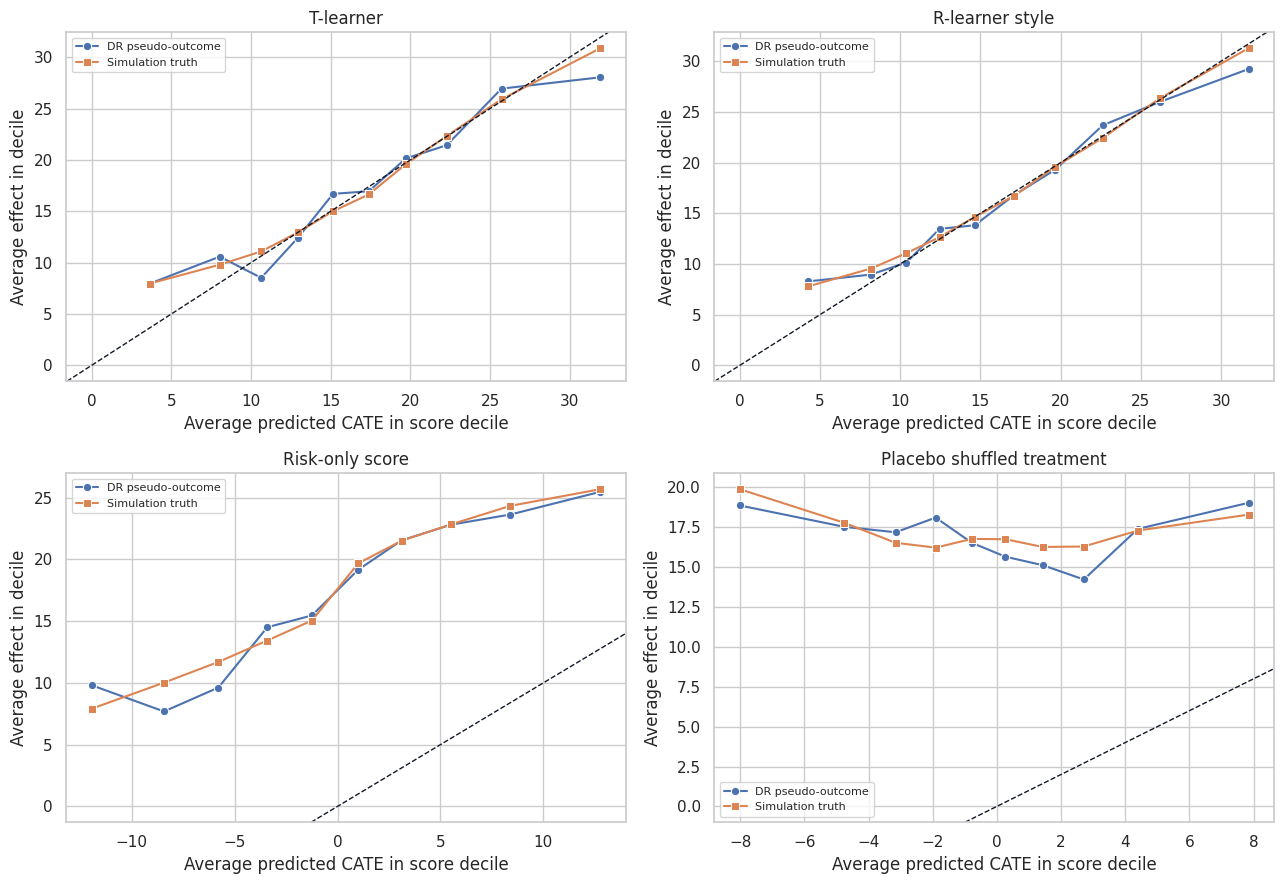

In [16]:
plot_models = ["T-learner", "R-learner style", "Risk-only score", "Placebo shuffled treatment"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False, sharey=False)

for ax, model in zip(axes.ravel(), plot_models):
    g = calibration_df[calibration_df["model"] == model]
    sns.lineplot(data=g, x="avg_pred", y="avg_dr", marker="o", label="DR pseudo-outcome", ax=ax)
    sns.lineplot(data=g, x="avg_pred", y="avg_true", marker="s", label="Simulation truth", ax=ax)
    ax.axline((0, 0), slope=1, color="#111827", linestyle="--", linewidth=1.0)
    ax.set_title(model)
    ax.set_xlabel("Average predicted CATE in score decile")
    ax.set_ylabel("Average effect in decile")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Calibration should be judged in groups, not one account at a time. Individual pseudo-outcomes are too noisy. Grouped calibration answers the more operational question: when the model says a segment is high effect, does that segment actually show high estimated lift?

## 10. Uplift and Targeting Curves

Many causal ML applications are ranking problems. We may not need perfect CATE magnitudes if the business only has capacity to treat the top 20% or top 30%.

A targeting curve sorts units by score and estimates cumulative gain:

$$
G(q) =
\frac{1}{n}
\sum_{i} 1\{\hat{\tau}(X_i)\text{ is in top }q\}\tau(X_i)
$$

In real data, replace $\tau(X_i)$ with a doubly robust score. Devriendt et al. (2022) discuss uplift modeling as a ranking problem, and uplift/Qini/AUUC-style metrics are widely used for this kind of validation.

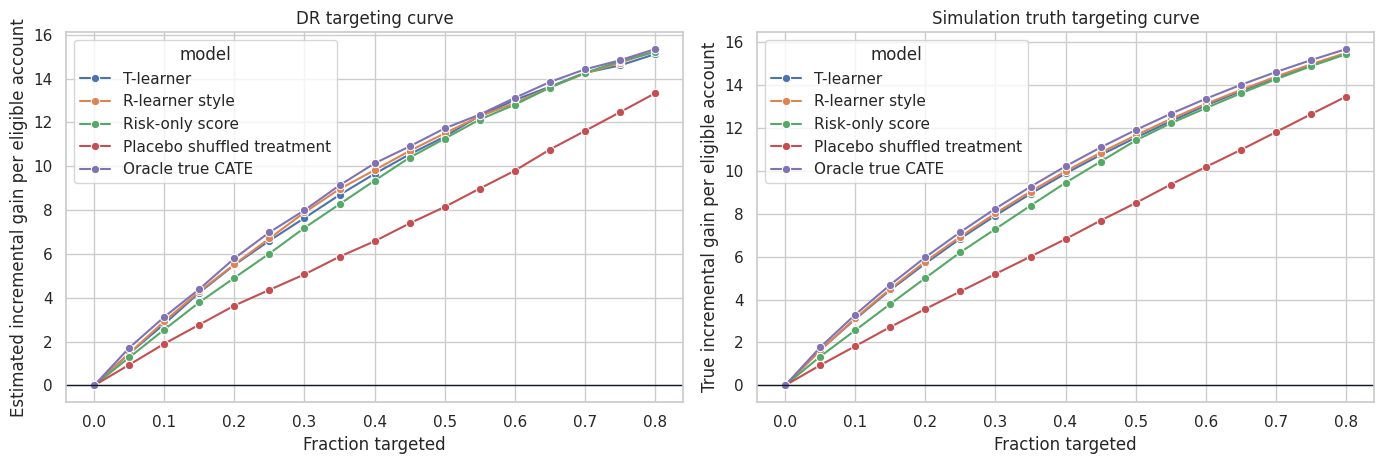

In [17]:
# Fit the models for this section and assemble the estimates used in the discussion.
def targeting_curve(frame, score_col, fractions):
    """Compute targeting curve for the causal ml model validation example.
    
    Inputs:
    - `frame`: pandas DataFrame containing the rows for this function and the causal variables named by the other arguments.
    - `score_col`: name of the model-score column used for ranking, targeting, or validation.
    - `fractions`: sequence of targeting fractions used to trace a value or uplift curve.
    Returns: a curve-ready table showing value or uplift as the policy threshold changes."""
    rows = []
    score = frame[score_col].to_numpy()
    for frac in fractions:
        mask = top_fraction_mask(score, frac, require_positive=False)
        rows.append(
            {
                "model": score_col,
                "fraction": frac,
                "treated_share": mask.mean(),
                "dr_gain": np.mean(mask * frame["dr_pseudo_tau"].to_numpy()),
                "true_gain": np.mean(mask * frame["true_tau"].to_numpy()),
            }
        )
    return pd.DataFrame(rows)


fractions = np.linspace(0, 0.80, 17)
curve_models = ["T-learner", "R-learner style", "Risk-only score", "Placebo shuffled treatment"]
curve_df = pd.concat([targeting_curve(valid_eval, col, fractions) for col in curve_models], ignore_index=True)
valid_eval["oracle_score"] = valid_eval["true_tau"]
oracle_df = targeting_curve(valid_eval, "oracle_score", fractions)
oracle_df["model"] = "Oracle true CATE"
oracle_df["true_gain"] = [
    np.mean(top_fraction_mask(valid_eval["true_tau"], frac) * valid_eval["true_tau"].to_numpy())
    for frac in fractions
]
oracle_df["dr_gain"] = [
    np.mean(top_fraction_mask(valid_eval["true_tau"], frac) * valid_eval["dr_pseudo_tau"].to_numpy())
    for frac in fractions
]
curve_df = pd.concat([curve_df, oracle_df], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.lineplot(data=curve_df, x="fraction", y="dr_gain", hue="model", marker="o", ax=axes[0])
axes[0].axhline(0, color="#111827", linewidth=1.0)
axes[0].set_title("DR targeting curve")
axes[0].set_xlabel("Fraction targeted")
axes[0].set_ylabel("Estimated incremental gain per eligible account")

sns.lineplot(data=curve_df, x="fraction", y="true_gain", hue="model", marker="o", ax=axes[1])
axes[1].axhline(0, color="#111827", linewidth=1.0)
axes[1].set_title("Simulation truth targeting curve")
axes[1].set_xlabel("Fraction targeted")
axes[1].set_ylabel("True incremental gain per eligible account")

plt.tight_layout()
plt.show()

This output should make the next modeling choice easier to defend. A useful CATE score has to survive calibration, overlap, stability, robustness, and policy-value checks.

In [18]:
def area_under_curve(curve, value_col):
    """Compute area under curve for the causal ml model validation example.
    
    Inputs:
    - `curve`: DataFrame containing curve points such as targeting fraction and cumulative value.
    - `value_col`: name of the curve column whose area should be summarized.
    Returns: a curve-ready table showing value or uplift as the policy threshold changes."""
    ordered = curve.sort_values("fraction")
    return np.trapezoid(ordered[value_col], ordered["fraction"])


auuc_rows = []
for model, group in curve_df.groupby("model"):
    auuc_rows.append(
        {
            "model": model,
            "DR_AUUC_like": area_under_curve(group, "dr_gain"),
            "true_AUUC_like_simulation_only": area_under_curve(group, "true_gain"),
        }
    )

display(pd.DataFrame(auuc_rows).sort_values("DR_AUUC_like", ascending=False))

,model,DR_AUUC_like,true_AUUC_like_simulation_only
0,Oracle true CATE,7.408,7.553
2,R-learner style,7.256,7.388
4,T-learner,7.193,7.331
3,Risk-only score,7.009,7.067
1,Placebo shuffled treatment,5.348,5.461


Targeting curves are often the most intuitive validation tool for stakeholders. They answer: if we treat the top $q$ percent according to the model, how much incremental value should we expect?

For observational data, use doubly robust or policy-value estimates. For randomized experiments with equal treatment probability, simpler uplift curves are also common.

## 11. Top-k Policy Value

Now evaluate a concrete capacity rule: treat the top 30% of accounts according to each score.

This is closer to how a model will actually be used. A CATE model with moderate PEHE can still be valuable if it ranks the top of the queue well.

In [19]:
capacity = 0.30
policy_rows = []
for col in candidate_cols:
    mask = top_fraction_mask(valid_eval[col], capacity, require_positive=False)
    dr_contrib = mask * valid_eval["dr_pseudo_tau"].to_numpy()
    true_contrib = mask * valid_eval["true_tau"].to_numpy()
    ci_low, ci_high = bootstrap_ci(dr_contrib, seed=5821, n_boot=400)
    policy_rows.append(
        {
            "model": col,
            "target_rate": mask.mean(),
            "DR_policy_gain": dr_contrib.mean(),
            "DR_ci_low": ci_low,
            "DR_ci_high": ci_high,
            "true_policy_gain_simulation_only": true_contrib.mean(),
            "avg_true_tau_selected": valid_eval.loc[mask == 1, "true_tau"].mean(),
        }
    )

policy_value_table = pd.DataFrame(policy_rows).sort_values("DR_policy_gain", ascending=False)
display(policy_value_table)

,model,target_rate,DR_policy_gain,DR_ci_low,DR_ci_high,true_policy_gain_simulation_only,avg_true_tau_selected
0,ATE baseline,1.000,16.968,16.244,17.603,17.212,17.212
4,R-learner style,0.300,7.892,7.321,8.418,8.010,26.699
2,S-learner,0.300,7.719,7.202,8.217,7.965,26.549
3,T-learner,0.300,7.640,7.170,8.128,7.909,26.363
1,Risk-only score,0.300,7.191,6.665,7.771,7.284,24.281
5,Placebo shuffled treatment,0.300,5.067,4.607,5.537,5.189,17.297


The result is most useful when it shapes the next action. Validation asks whether the score would make better treatment decisions, including cases where a predictive-looking pattern has little policy value.

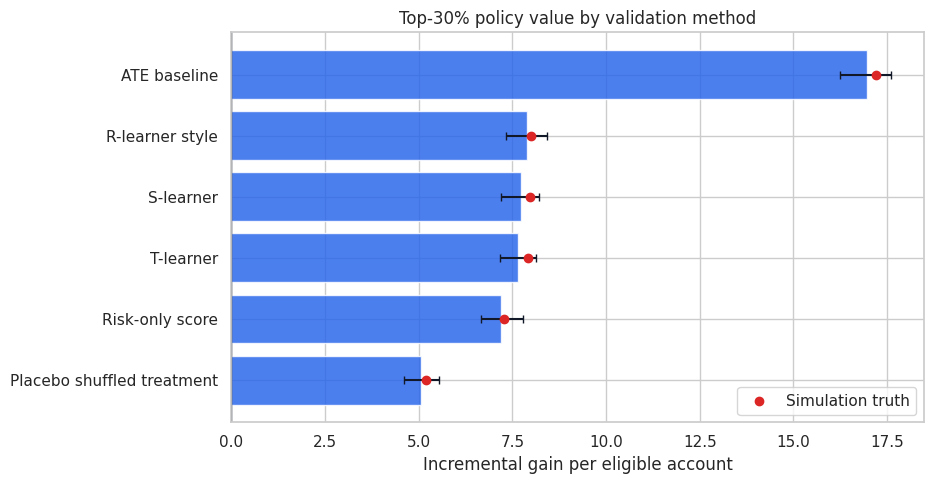

In [20]:
fig, ax = plt.subplots(figsize=(9.5, 5.0))
plot_data = policy_value_table.sort_values("DR_policy_gain")
ax.barh(plot_data["model"], plot_data["DR_policy_gain"], color="#2563eb", alpha=0.82)
ax.errorbar(
    x=plot_data["DR_policy_gain"],
    y=np.arange(len(plot_data)),
    xerr=[
        plot_data["DR_policy_gain"] - plot_data["DR_ci_low"],
        plot_data["DR_ci_high"] - plot_data["DR_policy_gain"],
    ],
    fmt="none",
    ecolor="#111827",
    capsize=3,
)
ax.scatter(plot_data["true_policy_gain_simulation_only"], np.arange(len(plot_data)), color="#dc2626", zorder=5, label="Simulation truth")
ax.axvline(0, color="#111827", linewidth=1.0)
ax.set_title("Top-30% policy value by validation method")
ax.set_xlabel("Incremental gain per eligible account")
ax.legend()
plt.tight_layout()
plt.show()

This table turns validation into a decision: which score would we actually use under a 30% capacity constraint? It also shows uncertainty, which is crucial when two models are close.

causal ML validation should check decision quality, calibration, ranking stability, overlap, and robustness together.

## 12. Overlap and Positivity by Score Band

Even a strong CATE score is risky if high-scored units live in regions with weak overlap. We need enough treated and untreated observations in the validation data to support the estimated contrast.

For each score decile, inspect:

- Average propensity.
- Treatment rate.
- Share with propensities near 0 or 1.
- Residual treatment variation.

In [21]:
score_for_overlap = "R-learner style"
overlap = valid_eval.copy()
overlap["score_decile"] = pd.qcut(overlap[score_for_overlap].rank(method="first"), 10, labels=False)
overlap_table = (
    overlap.groupby("score_decile", as_index=False)
    .agg(
        n=("account_id", "size"),
        avg_score=(score_for_overlap, "mean"),
        avg_e_hat=("e_hat", "mean"),
        treatment_rate=("treatment", "mean"),
        low_overlap_share=("e_hat", lambda s: np.mean((s < 0.10) | (s > 0.90))),
        residual_treatment_sd=("treatment", lambda s: np.std(s)),
        avg_dr_pseudo=("dr_pseudo_tau", "mean"),
        avg_true_tau=("true_tau", "mean"),
    )
)
display(overlap_table)

,score_decile,n,avg_score,avg_e_hat,treatment_rate,low_overlap_share,residual_treatment_sd,avg_dr_pseudo,avg_true_tau
0,0,440,4.261,0.414,0.375,0.000,0.484,8.283,7.792
1,1,440,8.170,0.412,0.420,0.002,0.494,8.956,9.548
2,2,440,10.386,0.448,0.459,0.000,0.498,10.145,11.068
3,3,440,12.453,0.471,0.486,0.000,0.500,13.461,12.647
4,4,440,14.644,0.499,0.514,0.005,0.500,13.822,14.638
5,5,440,17.095,0.545,0.518,0.014,0.500,16.782,16.720
6,6,440,19.673,0.591,0.623,0.005,0.485,19.311,19.610
7,7,440,22.621,0.649,0.611,0.011,0.487,23.678,22.431
8,8,440,26.223,0.729,0.750,0.061,0.433,26.011,26.379
9,9,440,31.715,0.807,0.811,0.184,0.391,29.232,31.287


This is a checkpoint for the design and the estimate together. The model earns trust by ranking effects well and by staying stable where the data have support.

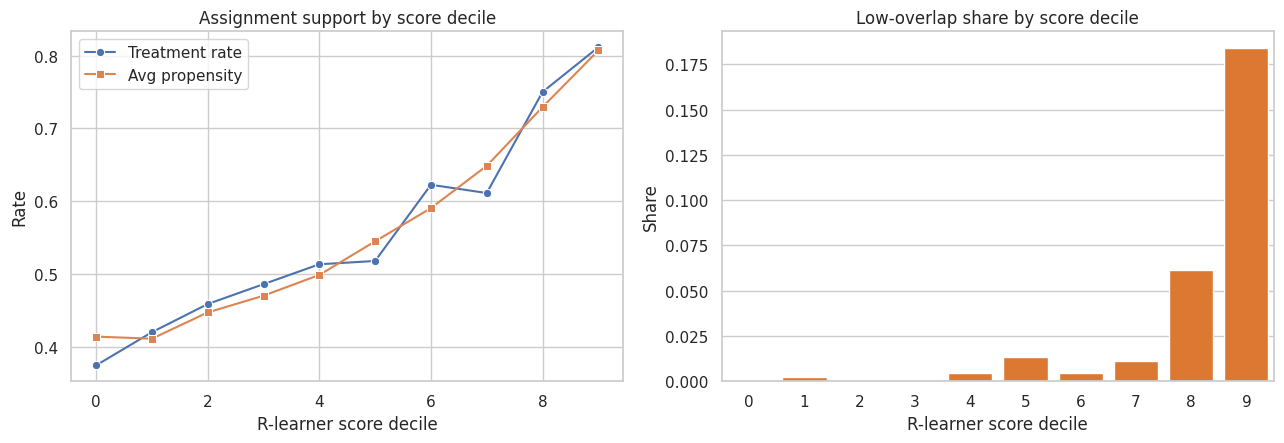

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.lineplot(data=overlap_table, x="score_decile", y="treatment_rate", marker="o", label="Treatment rate", ax=axes[0])
sns.lineplot(data=overlap_table, x="score_decile", y="avg_e_hat", marker="s", label="Avg propensity", ax=axes[0])
axes[0].set_title("Assignment support by score decile")
axes[0].set_xlabel("R-learner score decile")
axes[0].set_ylabel("Rate")
axes[0].legend()

sns.barplot(data=overlap_table, x="score_decile", y="low_overlap_share", color="#f97316", ax=axes[1])
axes[1].set_title("Low-overlap share by score decile")
axes[1].set_xlabel("R-learner score decile")
axes[1].set_ylabel("Share")

plt.tight_layout()
plt.show()

If the best-looking score sends decisions into low-overlap regions, the next step should be exploration or a randomized pilot, not blind deployment.

causal ML validation should check decision quality, calibration, ranking stability, overlap, and robustness together.

## 13. Stability Across Models

Good causal ML validation asks whether the recommendation depends on one fragile modeling choice.

We compare:

- Rank correlation across scores.
- Top-30% overlap across scores.
- Agreement between flexible and interpretable approaches.

Stability cannot prove correctness. Instability is a risk signal.

In [23]:
stability_models = ["S-learner", "T-learner", "R-learner style", "Risk-only score"]

rank_corr = valid_eval[stability_models].corr(method="spearman")
display(rank_corr)

top_masks = {m: top_fraction_mask(valid_eval[m], 0.30) for m in stability_models}
overlap_rows = []
for i, m1 in enumerate(stability_models):
    for m2 in stability_models[i + 1 :]:
        a = top_masks[m1].astype(bool)
        b = top_masks[m2].astype(bool)
        overlap_rows.append(
            {
                "model_a": m1,
                "model_b": m2,
                "top_30_jaccard": np.sum(a & b) / np.sum(a | b),
                "top_30_overlap_given_a": np.sum(a & b) / np.sum(a),
            }
        )

display(pd.DataFrame(overlap_rows).sort_values("top_30_jaccard", ascending=False))

,S-learner,T-learner,R-learner style,Risk-only score
S-learner,1.000,0.926,0.886,0.742
T-learner,0.926,1.000,0.896,0.700
R-learner style,0.886,0.896,1.000,0.705
Risk-only score,0.742,0.700,0.705,1.000


,model_a,model_b,top_30_jaccard,top_30_overlap_given_a
0,S-learner,T-learner,0.731,0.845
3,T-learner,R-learner style,0.690,0.817
1,S-learner,R-learner style,0.676,0.807
5,R-learner style,Risk-only score,0.451,0.622
2,S-learner,Risk-only score,0.443,0.614
4,T-learner,Risk-only score,0.439,0.611


The result matters because it changes what we would audit or do next. A useful CATE score has to survive calibration, overlap, stability, robustness, and policy-value checks.

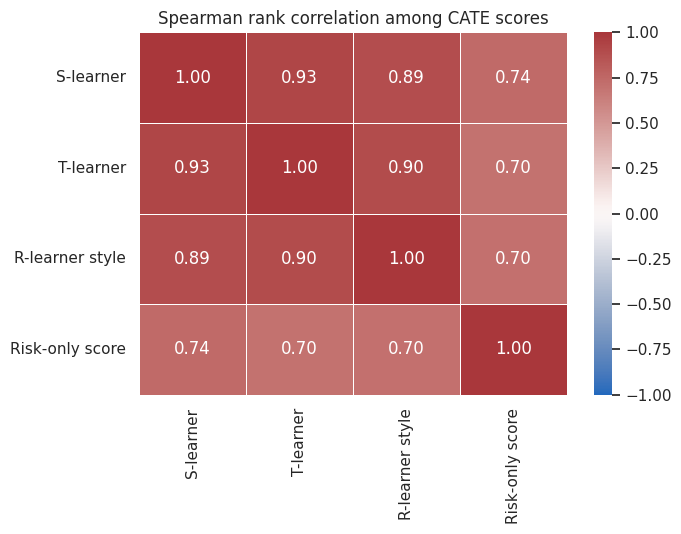

In [24]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(rank_corr, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("Spearman rank correlation among CATE scores")
plt.tight_layout()
plt.show()

The goal is not to force all models to agree. Different learners can capture different signals. But if the selected policy changes completely when the modeling recipe changes, that should be visible in the readout.

## 14. Placebo and Negative-Control Checks

A placebo check asks whether the pipeline finds treatment effects when it should not.

Here the placebo model was trained after shuffling treatment labels. It should perform poorly on PEHE, R-loss, calibration, and policy value. In real projects, related checks include:

- Placebo outcomes that should not respond to treatment.
- Pre-treatment outcomes.
- Randomized treatment labels.
- Future outcomes outside the plausible effect window.
- Segments where domain experts expect no effect.

These checks are validation screens. They catch overly eager pipelines.

In [25]:
# Fit the models for this section and assemble the estimates used in the discussion.
placebo_summary = pd.DataFrame(
    {
        "metric": [
            "Placebo PEHE, simulation only",
            "Placebo held-out R-loss",
            "Placebo top-30 DR policy gain",
            "Placebo top-30 true policy gain, simulation only",
            "R-learner top-30 DR policy gain",
            "R-learner top-30 true policy gain, simulation only",
        ],
        "value": [
            pehe_table.loc[pehe_table["model"] == "Placebo shuffled treatment", "PEHE_simulation_only"].iloc[0],
            r_loss_table.loc[r_loss_table["model"] == "Placebo shuffled treatment", "heldout_r_loss"].iloc[0],
            policy_value_table.loc[policy_value_table["model"] == "Placebo shuffled treatment", "DR_policy_gain"].iloc[0],
            policy_value_table.loc[
                policy_value_table["model"] == "Placebo shuffled treatment",
                "true_policy_gain_simulation_only",
            ].iloc[0],
            policy_value_table.loc[policy_value_table["model"] == "R-learner style", "DR_policy_gain"].iloc[0],
            policy_value_table.loc[
                policy_value_table["model"] == "R-learner style",
                "true_policy_gain_simulation_only",
            ].iloc[0],
        ],
    }
)
display(placebo_summary)

,metric,value
0,"Placebo PEHE, simulation only",19.773
1,Placebo held-out R-loss,145.470
2,Placebo top-30 DR policy gain,5.067
3,"Placebo top-30 true policy gain, simulation only",5.189
4,R-learner top-30 DR policy gain,7.892
5,"R-learner top-30 true policy gain, simulation ...",8.010


The placebo score should fail. If it passes, the validation metric may be treating baseline-risk sorting, leakage, or chance imbalances as causal lift.

causal ML validation should check decision quality, calibration, ranking stability, overlap, and robustness together.

## 15. Deployment Drift

Validation is not over when the notebook passes. A deployed targeting model faces future cohorts that may differ from the validation cohort.

We simulate a shifted future cohort with higher churn risk, lower product health, and more discount sensitivity. Then we compare feature and score distributions.

In [26]:
# Generate the teaching data and keep the causal quantities needed for diagnostics.
future = simulate_campaign_data(n=5000, seed=5822, shifted=True)
future["r_score"] = r_model.predict(future[feature_cols])
valid_eval["r_score"] = valid_eval["R-learner style"]

def psi(expected, actual, bins=10):
    """Compute the population stability index for drift monitoring.
    
    Inputs:
    - `expected`: reference distribution or baseline feature values in the drift diagnostic.
    - `actual`: new distribution or post-deployment feature values in the drift diagnostic.
    - `bins`: bin edges used to compare expected and actual distributions.
    Returns: a scalar PSI diagnostic comparing expected and actual feature distributions across bins."""
    quantiles = np.quantile(expected, np.linspace(0, 1, bins + 1))
    quantiles = np.unique(quantiles)
    expected_counts, _ = np.histogram(expected, bins=quantiles)
    actual_counts, _ = np.histogram(actual, bins=quantiles)
    expected_pct = np.clip(expected_counts / expected_counts.sum(), 1e-4, None)
    actual_pct = np.clip(actual_counts / actual_counts.sum(), 1e-4, None)
    return np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct))


drift_rows = []
for col in ["churn_risk", "product_health", "discount_sensitivity", "support_load", "r_score"]:
    drift_rows.append(
        {
            "variable": col,
            "validation_mean": valid_eval[col].mean() if col in valid_eval else valid_eval["r_score"].mean(),
            "future_mean": future[col].mean(),
            "mean_shift": future[col].mean() - (valid_eval[col].mean() if col in valid_eval else valid_eval["r_score"].mean()),
            "PSI": psi(valid_eval[col].to_numpy() if col in valid_eval else valid_eval["r_score"].to_numpy(), future[col].to_numpy()),
        }
    )

drift_table = pd.DataFrame(drift_rows).sort_values("PSI", ascending=False)
display(drift_table)

,variable,validation_mean,future_mean,mean_shift,PSI
2,discount_sensitivity,0.431,0.511,0.079,0.155
4,r_score,16.724,19.767,3.043,0.141
1,product_health,0.551,0.471,-0.079,0.131
0,churn_risk,0.463,0.508,0.045,0.083
3,support_load,1.632,1.992,0.360,0.060


At this point the lecture becomes practical. Validation asks whether the score would make better treatment decisions, including cases where a predictive-looking pattern has little policy value.

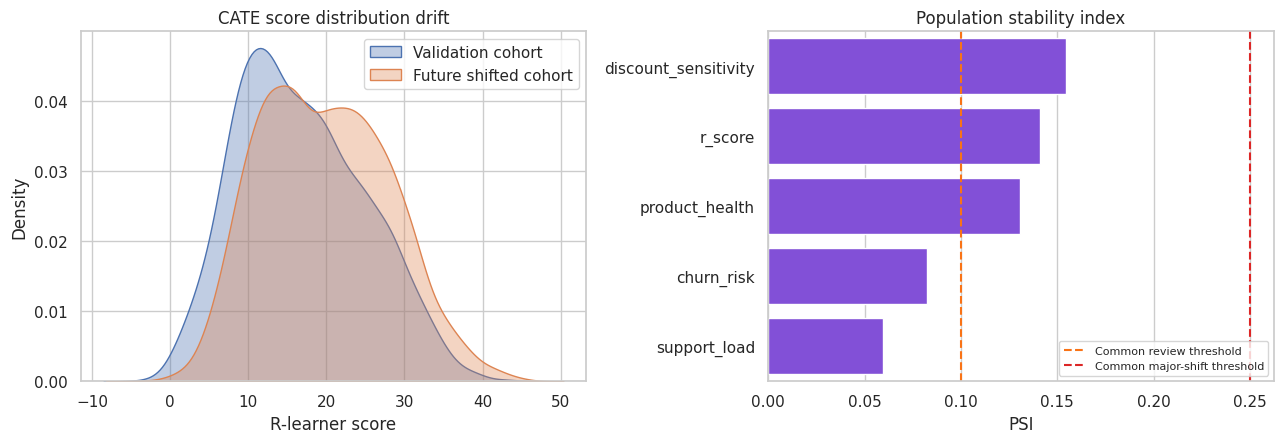

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

sns.kdeplot(valid_eval["r_score"], label="Validation cohort", fill=True, alpha=0.35, ax=axes[0])
sns.kdeplot(future["r_score"], label="Future shifted cohort", fill=True, alpha=0.35, ax=axes[0])
axes[0].set_title("CATE score distribution drift")
axes[0].set_xlabel("R-learner score")
axes[0].legend()

sns.barplot(data=drift_table, y="variable", x="PSI", color="#7c3aed", ax=axes[1])
axes[1].axvline(0.10, color="#f97316", linestyle="--", label="Common review threshold")
axes[1].axvline(0.25, color="#dc2626", linestyle="--", label="Common major-shift threshold")
axes[1].set_title("Population stability index")
axes[1].set_xlabel("PSI")
axes[1].set_ylabel("")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Drift diagnostics do not estimate causal validity by themselves. They tell us whether the deployment population still looks like the population where the model was validated. Major drift should trigger recalibration, revalidation, or a new experiment.

## 16. A Practical Validation Checklist

For an industry causal ML system, validation should include:

1. Identification review: treatment timing, confounders, leakage, positivity, and estimand.
2. Data split discipline: train, validation, and final test or prospective pilot.
3. Nuisance diagnostics: outcome model, propensity model, residual treatment variation.
4. CATE diagnostics: R-loss, calibration, ranking curves, policy value.
5. Robustness: alternative learners, hyperparameters, subgroup stability, and placebo checks.
6. Decision diagnostics: top-k value, cost-adjusted value, capacity, fairness, and operational constraints.
7. Monitoring: feature drift, score drift, action-rate drift, realized outcomes, and experimental holdouts.
8. Human review: interpretability, domain plausibility, and escalation paths.

Causal ML validation is not one number. It is a chain of evidence.

In [28]:
# Fit the models for this section and assemble the estimates used in the discussion.
best_model = policy_value_table.iloc[0]["model"]
best_policy = policy_value_table.iloc[0]
best_r_loss = r_loss_table.loc[r_loss_table["model"] == best_model, "heldout_r_loss"].iloc[0]
best_pehe = pehe_table.loc[pehe_table["model"] == best_model, "PEHE_simulation_only"].iloc[0]

readout = pd.DataFrame(
    {
        "item": [
            "Recommended score by held-out top-30 DR value",
            "Held-out R-loss",
            "Top-30 DR policy gain",
            "Approximate 95% CI for top-30 gain",
            "Simulation-only PEHE",
            "Simulation-only true top-30 gain",
            "Main validation caveat",
            "Recommended next step",
        ],
        "value": [
            best_model,
            f"{best_r_loss:.2f}",
            f"{best_policy['DR_policy_gain']:.2f}",
            f"[{best_policy['DR_ci_low']:.2f}, {best_policy['DR_ci_high']:.2f}]",
            f"{best_pehe:.2f}",
            f"{best_policy['true_policy_gain_simulation_only']:.2f}",
            "DR validation depends on nuisance quality and overlap.",
            "Run a randomized pilot or maintain an exploration holdout before full automation.",
        ],
    }
)
display(readout)

,item,value
0,Recommended score by held-out top-30 DR value,ATE baseline
1,Held-out R-loss,84.69
2,Top-30 DR policy gain,16.97
3,Approximate 95% CI for top-30 gain,"[16.24, 17.60]"
4,Simulation-only PEHE,8.44
5,Simulation-only true top-30 gain,17.21
6,Main validation caveat,DR validation depends on nuisance quality and ...
7,Recommended next step,Run a randomized pilot or maintain an explorat...


## Key Takeaways

- Causal ML validation is different because individual treatment effects are unobserved.
- Outcome-prediction metrics do not validate treatment-effect accuracy.
- PEHE is useful in simulation but unavailable in ordinary business data.
- Held-out R-loss is a practical model-selection criterion for CATE scores.
- Doubly robust pseudo-outcomes help evaluate grouped calibration and targeting value.
- Uplift and targeting curves are often the clearest way to communicate ranking performance.
- Top-k policy value links validation to operational capacity.
- Placebo checks catch pipelines that manufacture heterogeneity.
- Overlap and drift diagnostics are model-risk controls, not optional appendices.
- The strongest validation is still prospective: randomized pilots, exploration holdouts, or staged rollouts.

## References

Devriendt, F., Guns, T., & Verbeke, W. (2022). Learning to rank for uplift modeling. *IEEE Transactions on Knowledge and Data Engineering, 34*(10), 4888-4904. https://doi.org/10.1109/tkde.2020.3048510

Gao, Z., Hastie, T., & Tibshirani, R. (2020). Assessment of heterogeneous treatment effect estimation accuracy via matching. arXiv. https://doi.org/10.48550/arxiv.2003.03881

Nie, X., & Wager, S. (2020). Quasi-oracle estimation of heterogeneous treatment effects. *Biometrika, 108*(2), 299-319. https://doi.org/10.1093/biomet/asaa076

Rothenhausler, D. (2020). Model selection for estimation of causal parameters. arXiv. https://doi.org/10.48550/arxiv.2008.12892

Xu, Y., & Yadlowsky, S. (2022). Calibration error for heterogeneous treatment effects. arXiv. https://doi.org/10.48550/arxiv.2203.13364
